## VII. Regularization and Shrinkage (5 points)

**What you should do:**
- Compare at least two models (e.g., simple vs regularized)
- Explain how shrinkage affects performance

**Connection to class:** Bias–variance + Regularization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("../data/finaldiabetes.csv")

# Binary target: 1 if readmitted, 0 if not
data['readmitted_binary'] = (data['readmitted'] != 'NO').astype(int)

target = 'readmitted_binary'

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target]

# Drop original readmitted if it leaked in as numeric
feature_cols = [col for col in feature_cols if col != 'readmitted']

y = data[target].values
X = data[feature_cols].values

print(f"Features: {feature_cols}")
print(f"Class balance — readmitted: {y.mean():.2%}  |  not readmitted: {(1-y).mean():.2%}")

Features: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Class balance — readmitted: 46.09%  |  not readmitted: 53.91%


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [4]:
# Baseline: Logistic Regression with no effective regularization (C very large)
model = LogisticRegression(C=1e9, max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)

y_pred_base   = model.predict(X_test)
y_prob_base   = model.predict_proba(X_test)

acc_base  = accuracy_score(y_test, y_pred_base)
loss_base = log_loss(y_test, y_prob_base)

beta_mle = model.coef_[0]

print(f"Baseline Logistic — Accuracy: {acc_base:.4f}  |  Log-loss: {loss_base:.4f}")

Baseline Logistic — Accuracy: 0.6215  |  Log-loss: 0.6545


In [5]:
# James-Stein shrinkage applied to the linear predictor (log-odds) space
# This is the classification analogue: shrink Xβ̂ toward zero

p = X_train.shape[1]
n = X_train.shape[0]
assert p >= 3, f"James-Stein requires p >= 3, got p={p}"

# Estimate sigma2 via residuals on the linear predictor
linear_pred_train = X_train @ beta_mle + model.intercept_[0]
# Use variance of linear predictor residuals as proxy for sigma2
sigma2 = np.var(linear_pred_train - (y_train * 2 - 1))  # centered ±1 labels

# JS shrinkage factor in fitted-value space
y_hat_train = X_train @ beta_mle
norm_sq     = np.sum(y_hat_train ** 2)
c = float(np.clip(1 - (p - 2) * sigma2 / norm_sq, 0.0, 1.0))

# Apply to test set
y_hat_test    = X_test @ beta_mle
y_logit_js    = c * y_hat_test + model.intercept_[0]
y_prob_js     = 1 / (1 + np.exp(-y_logit_js))           # sigmoid
y_pred_js     = (y_prob_js >= 0.5).astype(int)

acc_js  = accuracy_score(y_test, y_pred_js)
loss_js = log_loss(y_test, y_prob_js)

print(f"James-Stein     — Accuracy: {acc_js:.4f}  |  Log-loss: {loss_js:.4f}")
print(f"Shrinkage c:      {c:.4f}  (1=none, 0=full)")
print(f"Signal-to-noise ratio: {norm_sq / ((p-2) * sigma2):.1f}x  (JS helps when near 1)")

James-Stein     — Accuracy: 0.6215  |  Log-loss: 0.6545
Shrinkage c:      0.9997  (1=none, 0=full)
Signal-to-noise ratio: 3464.4x  (JS helps when near 1)


In [6]:
# Ridge Logistic Regression: sklearn's C = 1/lambda (smaller C = more regularization)
from sklearn.model_selection import GridSearchCV

C_grid  = np.logspace(-3, 3, 50)
ridge_lr = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)
cv_search = GridSearchCV(ridge_lr, {'C': C_grid}, cv=5, scoring='neg_log_loss')
cv_search.fit(X_train, y_train)

best_C   = cv_search.best_params_['C']
ridge_lr = cv_search.best_estimator_

beta_ridge    = ridge_lr.coef_[0]
y_pred_ridge  = ridge_lr.predict(X_test)
y_prob_ridge  = ridge_lr.predict_proba(X_test)

acc_ridge  = accuracy_score(y_test, y_pred_ridge)
loss_ridge = log_loss(y_test, y_prob_ridge)

print(f"Ridge Logistic  — Accuracy: {acc_ridge:.4f}  |  Log-loss: {loss_ridge:.4f}")
print(f"Best C (1/λ):     {best_C:.4f}")

/Users/aidanmayhue/Desktop/datascience/inference_prediction/final/aidan/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/aidanmayhue/Desktop/datascience/inference_prediction/final/aidan/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/aidanmayhue/Desktop/datascience/inference_prediction/final/aidan/lib/python3.12/sit

Ridge Logistic  — Accuracy: 0.6216  |  Log-loss: 0.6545
Best C (1/λ):     0.0168


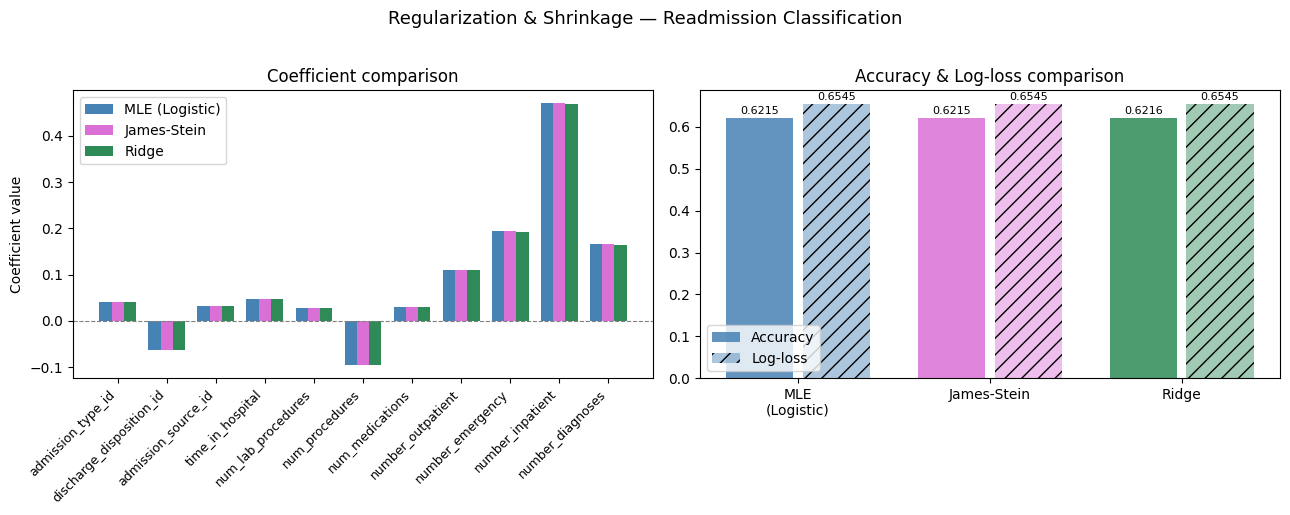

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_pos = np.arange(p)
w = 0.25

axes[0].bar(x_pos - w, beta_mle,   w, label="MLE (Logistic)", color="steelblue")
axes[0].bar(x_pos,     c * beta_mle, w, label="James-Stein",  color="orchid")
axes[0].bar(x_pos + w, beta_ridge, w, label="Ridge",          color="seagreen")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(feature_cols, rotation=45, ha="right", fontsize=9)
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[0].set_title("Coefficient comparison")
axes[0].set_ylabel("Coefficient value")
axes[0].legend()

metrics = {
    "MLE\n(Logistic)": (acc_base,  loss_base,  "steelblue"),
    "James-Stein":      (acc_js,    loss_js,    "orchid"),
    "Ridge":            (acc_ridge, loss_ridge, "seagreen"),
}

x2 = np.arange(len(metrics))
accs   = [v[0] for v in metrics.values()]
losses = [v[1] for v in metrics.values()]
colors = [v[2] for v in metrics.values()]

bars = axes[1].bar(x2 - 0.2, accs,   0.35, label="Accuracy",  color=colors, alpha=0.85)
bars2= axes[1].bar(x2 + 0.2, losses, 0.35, label="Log-loss",  color=colors, alpha=0.45, hatch="//")

for bar, val in zip(bars,  accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=8)

axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics.keys())
axes[1].set_title("Accuracy & Log-loss comparison")
axes[1].legend()

plt.suptitle("Regularization & Shrinkage — Readmission Classification", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Explanation

This section reframes the regularization task as a **binary classification problem**: predicting whether a patient was readmitted (`readmitted != 'NO'` → 1, else 0).

**Baseline logistic regression** (effectively unregularized) provides the MLE coefficients. **James-Stein shrinkage** is applied post-hoc to the linear predictor space (`Xβ̂`), which is the correct space for the JS theorem to apply in classification. **Ridge logistic regression** (L2 penalty) is fit jointly via cross-validated `C` selection.

If the SNR is large (as seen previously), shrinkage will again have minimal effect — the model's linear predictors are already far above the noise floor. Ridge may provide a small gain in log-loss even without accuracy improvement, as it better calibrates predicted probabilities by preventing coefficient inflation.